# knn -> K-Nearest Neighbors -> supervised learning algorithm used for classification and regression tasks
1. K -> number of nearest neighbors to consider
2. distance metric -> how to measure distance between data points (e.g., Euclidean, Manhattan, Minkowski)
3. weighted knn -> assign weights to neighbors based on distance (closer neighbors have more influence)
4. K choose -> cross-validation and grid search to find optimal K value

# apis
1. from sklearn.neighbors import KNeighborsClassifier
2. from sklearn.neighbors import KNeighborsRegressor
3. k default in sklearn is 5

# regression
1. calculate distance between new data point and all training data points
2. sort the training data points ascending order based on distance
3. take k numbers data points with the smallest distance
4. calculate which type is most common in k numbers data points with majority vote rule
5.assign the unknown data point to the most common type

# classification
1. calculate distance between new data point and all training data points
2. sort the training data points ascending order based on distance
3. take k numbers data points with the smallest distance
4.  calculate the mean value of the target variable for the k nearest neighbors
5. assign the unknown data point to the type this mean value as the predicted value

# distance metric
1. Euclidean distance -> sqrt(sum((x_i - y_i)^2))
2. Manhattan distance -> sum(|x_i - y_i|)
3. Chebyshev distance -> max(|x_i - y_i|)
4. Minkowski distance -> (sum(|x_i - y_i|^p))^(1/p)

# Feature Preprocessing
1. Standardization -> (x - mean) / std -> from sklearn.preprocessing import StandardScaler
2. Normalization -> (x - min) / (max - min) -> 0 to 1 scaling
3. Scaling -> (x - min) / (max - min) * (max - min) + min ->from sklearn.preprocessing import MinMaxScaler ->scaler = MinMaxScaler(feature_range=(0, 1))


# Normalization is used to traditional small datasets
# Standardization is used to large datasets

# demo for Iris dataset
1. load the dataset
2. process the data (e.g., handle missing values, encode categorical variables, feature scaling)
3. feature engineering (e.g., create new features, select relevant features)
4. split the dataset into training and testing sets
5. train
6. evaluate the model (e.g., accuracy, precision, recall, F1-score)

In [3]:
from colorsys import yiq_to_rgb

from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from  sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score

In [4]:
# show iris dataset info
def demo1_loadiris():
    mydataSet = load_iris()
    print("check dataset info ->\n", mydataSet.data[:5])
    print('check dataset target ->\n', mydataSet.target)
    print('check dataset target names ->\n', mydataSet.target_names)
    print('check dataset feature names ->\n', mydataSet.feature_names)
    print('check dataset description ->\n', mydataSet.DESCR)
    print('check dataset filename ->\n', mydataSet.filename)
    print('check dataset keys ->\n', mydataSet.keys())
    print('check dataset data shape ->\n', mydataSet.data.shape)
    print('check dataset target shape ->\n', mydataSet.target.shape)
    print('check dataset target names shape ->\n', mydataSet.target_names.shape)
    return mydataSet

In [5]:
# change iris dataset type to panda dataframe and add target as label column
iris_data = demo1_loadiris()

check dataset info ->
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
check dataset target ->
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
check dataset target names ->
 ['setosa' 'versicolor' 'virginica']
check dataset feature names ->
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
check dataset description ->
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in c

In [6]:
iris_data = load_iris()
iris_df = pd.DataFrame(iris_data['data'], columns=iris_data.feature_names)
iris_df['label'] = iris_data['target'] # dict type or pandas dataframe type
# iris_df['label'] = iris_data.target   attribute type
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  


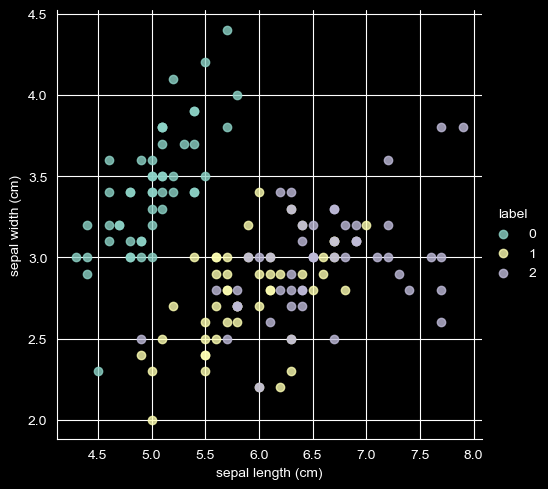

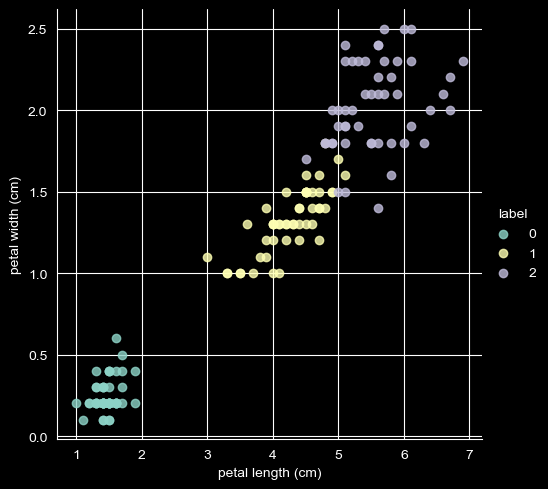

In [7]:
sns.lmplot(x='sepal length (cm)', y='sepal width (cm)', data=iris_df, hue='label', fit_reg=False)
sns.lmplot(x='petal length (cm)', y='petal width (cm)', data=iris_df, hue='label', fit_reg=False)
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=123)

In [9]:
X_train

array([[7.4, 2.8, 6.1, 1.9],
       [6. , 2.2, 5. , 1.5],
       [4.7, 3.2, 1.6, 0.2],
       [5.1, 3.5, 1.4, 0.2],
       [6. , 2.2, 4. , 1. ],
       [5. , 2.3, 3.3, 1. ],
       [7.9, 3.8, 6.4, 2. ],
       [5.4, 3.9, 1.7, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.8, 2.7, 3.9, 1.2],
       [5. , 2. , 3.5, 1. ],
       [5. , 3.2, 1.2, 0.2],
       [6.8, 3.2, 5.9, 2.3],
       [6.7, 3. , 5.2, 2.3],
       [5.8, 2.7, 5.1, 1.9],
       [5.8, 2.8, 5.1, 2.4],
       [6.3, 3.4, 5.6, 2.4],
       [5.5, 2.3, 4. , 1.3],
       [5.1, 3.8, 1.5, 0.3],
       [4.4, 3. , 1.3, 0.2],
       [6.5, 3.2, 5.1, 2. ],
       [5.1, 3.3, 1.7, 0.5],
       [4.9, 3.1, 1.5, 0.1],
       [6.7, 3.1, 4.7, 1.5],
       [6.1, 3. , 4.6, 1.4],
       [5.5, 2.5, 4. , 1.3],
       [5.7, 2.6, 3.5, 1. ],
       [5.8, 2.7, 5.1, 1.9],
       [6.7, 3.1, 4.4, 1.4],
       [6.4, 3.2, 5.3, 2.3],
       [4.5, 2.3, 1.3, 0.3],
       [6.7, 3.3, 5.7, 2.1],
       [5.7, 3. , 4.2, 1.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.8, 3

In [10]:
len(X_train), len(X_test)

(120, 30)

In [11]:
# feature scaling
transformer = StandardScaler()
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)
# train
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
knnscore = knn.score(X_test, y_test)
y_predict = knn.predict(X_test)
accuracy_test = accuracy_score(y_test, y_predict)
print("accuracy_test -> ", accuracy_test)
print("knn classification score -> ", knnscore)

accuracy_test ->  0.9
knn classification score ->  0.9


In [12]:
print('knn classes -> ', knn.classes_)
test_data = [[5.1, 3.5, 1.4, 0.2], [6.2, 3.4, 5.4, 2.3]]
test_data = transformer.transform(test_data)
test_predict = knn.predict(test_data)
test_predict_proba = knn.predict_proba(test_data) # return probability of each class
print("knn predict -> ", test_predict)
print("knn predict proba -> ", test_predict_proba)

knn classes ->  [0 1 2]
knn predict ->  [0 2]
knn predict proba ->  [[1. 0. 0.]
 [0. 0. 1.]]


# Cross Validation and Grid Search for K value
1. Cross Validation -> K-Fold Cross Validation -> split the dataset into K folds, train the model on K-1 folds and test on the remaining fold, repeat K times and average the results
2. Grid Search -> search for the best hyperparameters (e.g., K value)
in reality, we can use GridSearchCV from sklearn to perform cross validation and grid search for K value
Cross Validation solve the dataset split issue and Grid Search solve the hyperparameter tuning issue


In [22]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': [1, 3, 5, 7,9,20]}
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=4)
grid_search.fit(X_train, y_train)
print("estimator -> ", grid_search.estimator)
print("cv_results -> ", grid_search.cv_results_)
print("score -> ", grid_search.best_score_)
print("best K value -> ", grid_search.best_params_)

estimator ->  KNeighborsClassifier(n_neighbors=3)
cv_results ->  {'mean_fit_time': array([0.0017485 , 0.00124913, 0.00100189, 0.00100851, 0.00101006,
       0.0005095 ]), 'std_fit_time': array([4.34669973e-04, 4.33842630e-04, 2.78233052e-06, 8.61446942e-06,
       2.38183024e-05, 5.09645074e-04]), 'mean_score_time': array([0.00225383, 0.00225091, 0.00174832, 0.00224811, 0.00199723,
       0.00247473]), 'std_score_time': array([4.32094042e-04, 4.34703078e-04, 4.32095937e-04, 8.27740591e-04,
       1.12272116e-05, 4.89364352e-04]), 'param_n_neighbors': masked_array(data=[1, 3, 5, 7, 9, 20],
             mask=[False, False, False, False, False, False],
       fill_value=999999), 'params': [{'n_neighbors': 1}, {'n_neighbors': 3}, {'n_neighbors': 5}, {'n_neighbors': 7}, {'n_neighbors': 9}, {'n_neighbors': 20}], 'split0_test_score': array([0.9       , 1.        , 1.        , 0.96666667, 0.96666667,
       0.9       ]), 'split1_test_score': array([0.93333333, 0.93333333, 0.93333333, 0.9333333

In [38]:
s = knn.score(X_test, y_test)
sg = grid_search.score(X_test, y_test) # use the last model not the best model  to predict the test set
print(s)
print(sg)

0.9
0.9


In [37]:
mores = pd.DataFrame(grid_search.cv_results_)
print(mores)
mores.to_csv('./knn_cv_results.csv', index=False)# predict

   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.001749      0.000435         0.002254        0.000432   
1       0.001249      0.000434         0.002251        0.000435   
2       0.001002      0.000003         0.001748        0.000432   
3       0.001009      0.000009         0.002248        0.000828   
4       0.001010      0.000024         0.001997        0.000011   
5       0.000510      0.000510         0.002475        0.000489   

   param_n_neighbors               params  split0_test_score  \
0                  1   {'n_neighbors': 1}           0.900000   
1                  3   {'n_neighbors': 3}           1.000000   
2                  5   {'n_neighbors': 5}           1.000000   
3                  7   {'n_neighbors': 7}           0.966667   
4                  9   {'n_neighbors': 9}           0.966667   
5                 20  {'n_neighbors': 20}           0.900000   

   split1_test_score  split2_test_score  split3_test_score  mean_test_score  \
0 